# 1. Land Surface Temperature Summer vs Winter

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load data
df = pd.read_csv("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/data/csv/lst_zonal_lc_season_csv.csv")

# Add Temperature difference between Winter and winter
# ensure clean data
df = df.copy()


# reshape so winter and Winter become columns
df_pivot = df.pivot_table(
    index=["gridcode", "lc", "lc_0"],
    columns="season",
    values=["min", "max", "mean", "std", "median"]
)

# flatten column names
df_pivot.columns = ['_'.join(col) for col in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# compute differences (winter - Winter)
df_pivot["min"] = df_pivot["min_Summer"] - df_pivot["min_Winter"]
df_pivot["max"] = df_pivot["max_Summer"] - df_pivot["max_Winter"]
df_pivot["mean"] = df_pivot["mean_Summer"] - df_pivot["mean_Winter"]
df_pivot["std"] = df_pivot["std_Summer"] - df_pivot["std_Winter"]
df_pivot["median"] = df_pivot["median_Summer"] - df_pivot["median_Winter"]

# add season label
df_pivot["season"] = "Summer - Winter"

# final output
df_diff = df_pivot[["season",
    "gridcode", "lc", "lc_0",
    "min", "max", "mean",
    "std", "median"
]]

print(df_diff)


            season  gridcode                   lc                      lc_0  \
0  Summer - Winter         0             1. Water                     Water   
1  Summer - Winter         1       3. Residential               Residential   
2  Summer - Winter         2        4. Industrial  Large low-rise buildings   
3  Summer - Winter         3         6. Wet grass           Irrigated grass   
4  Summer - Winter         4            2. Forest                    Forest   
5  Summer - Winter         5  7. Summer dry grass          Summer dry grass   
6  Summer - Winter         6         5. Bare soil                 Bare soil   
7  Summer - Winter        10  8. Winter dry grass          Winter dry grass   

      min     max    mean    std  median  
0  14.017  21.640  13.802  1.025  13.769  
1  16.457  24.934  23.896  0.429  23.795  
2  20.400  25.064  23.797  0.733  23.998  
3  17.310  26.752  22.430  0.553  22.626  
4  18.179  25.401  22.000  1.082  22.150  
5  21.656  26.374  25.032  0.6

In [138]:
# concat df with df_diff
df = pd.concat([df, df_diff], axis=0, ignore_index=True)

print(df)

             season  gridcode                   lc                      lc_0  \
0            Summer         0             1. Water                     Water   
1            Summer         1       3. Residential               Residential   
2            Summer         2        4. Industrial  Large low-rise buildings   
3            Summer         3         6. Wet grass           Irrigated grass   
4            Summer         4            2. Forest                    Forest   
5            Summer         5  7. Summer dry grass          Summer dry grass   
6            Summer         6         5. Bare soil                 Bare soil   
7            Summer        10  8. Winter dry grass          Winter dry grass   
8            Winter         0             1. Water                     Water   
9            Winter         1       3. Residential               Residential   
10           Winter         2        4. Industrial  Large low-rise buildings   
11           Winter         3         6.

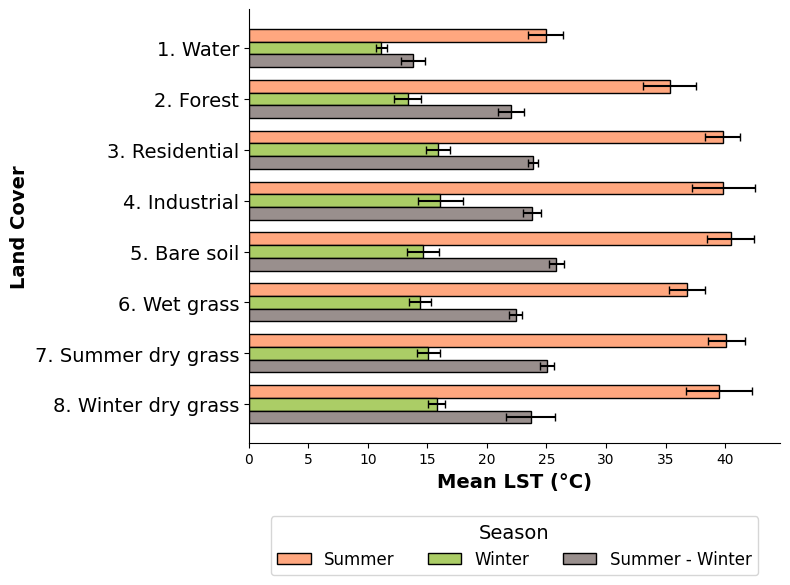

In [146]:
# Colors
lc_colors = {
    "Summer": "#FFA77F",
    "Winter": "#ABCD66",
    "Summer - Winter": "#998F8D"
}

# Categories
lc_categories = sorted(df["lc"].unique())
seasons = ["Summer", "Winter", "Summer - Winter"]

# y positions (because LC is now vertical axis)
y = np.arange(len(lc_categories))
height = 0.25

plt.figure(figsize=(8, 6))

for i, season in enumerate(seasons):
    subset = df[df["season"] == season]

    means = []
    stds = []

    for lc in lc_categories:
        row = subset[subset["lc"] == lc]

        if not row.empty:
            means.append(row["mean"].values[0])
            stds.append(row["std"].values[0])
        else:
            means.append(np.nan)
            stds.append(np.nan)

    plt.barh(
        y + i * height - height,
        means,
        height,
        label=season,
        color=lc_colors[season],
        edgecolor="black"
    )

    plt.errorbar(
        means,
        y + i * height - height,
        xerr=stds,
        fmt="none",
        ecolor="black",
        capsize=3
    )

# Labels
plt.xlabel("Mean LST (°C)", fontsize=14, fontweight="bold")
plt.ylabel("Land Cover", fontsize=14, fontweight="bold")

plt.yticks(y, lc_categories, fontsize=14)
plt.gca().invert_yaxis()


plt.legend(title="Season", fontsize=12, title_fontsize=14)

# Clean style
ax = plt.gca()
ax.set_facecolor("white")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Legend at the bottom
plt.legend(
    title="Season",
    fontsize=12,
    title_fontsize=14,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)

plt.tight_layout()

# Save
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/lst_summer_winter_difference_land_cover.png", dpi=300, bbox_inches="tight")

plt.show()

# 2. Turning Points
## 2.1 Minimum LST after leaving the reference (x=0)
### 2.1.1 Summer

In [147]:
from pygam import GAM, s

# Load data
summer_df = pd.read_csv("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/data/csv/lst_2023.csv")

# Keep distances < 31
summer_df = summer_df[summer_df["distance"] < 31]

# Ensure correct type
summer_df["direction"] = summer_df["direction"].astype(str)


In [142]:
# 2. Fit GAM curves + compute turning points
summer_df_spline_list = []
summer_turning_points = []

for direction, group in summer_df.groupby("direction"):
    
    group = group.sort_values("distance")
    
    X = group["distance"].values.reshape(-1, 1)
    y = group["mean_lst"].values
    
    # Fit GAM
    gam = GAM(s(0, spline_order=3)).fit(X, y)
    
    # Predict on original distances (for plotting consistency)
    pred = gam.predict(X)
    
    # Force exact value at distance = 0
    idx0 = np.where(group["distance"].values == 0)[0]
    if len(idx0) == 1:
        pred[idx0[0]] = y[idx0[0]]
    
    # Store smoothed curve
    temp = pd.DataFrame({
        "distance": group["distance"].values,
        "mean_lst": pred,
        "direction": direction
    })
    summer_df_spline_list.append(temp)
    
    # --------------------------
    # Turning point calculation
    # --------------------------
    
    # Only compute turning points for selected directions
    if direction in ["315", "345"]:
        
        x_vals = group["distance"].values
        
        # Reference LST at distance = 0
        if len(idx0) == 1:
            y0 = pred[idx0[0]]
        else:
            y0 = pred[0]
        
        # Only consider cooling (below starting LST)
        mask = pred < y0
        
        if np.any(mask):
            idx_min = np.argmin(pred[mask])
            x_valid = x_vals[mask]
            y_valid = pred[mask]
            
            summer_turning_points.append({
                "direction": direction,
                "distance": x_valid[idx_min],
                "lst": y_valid[idx_min]
            })


# Combine curves
summer_df_spline = pd.concat(summer_df_spline_list, ignore_index=True)

# Turning points table
summer_df_turning = pd.DataFrame(summer_turning_points)

print(summer_df_turning)


  direction  distance        lst
0       345        25  37.908758


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


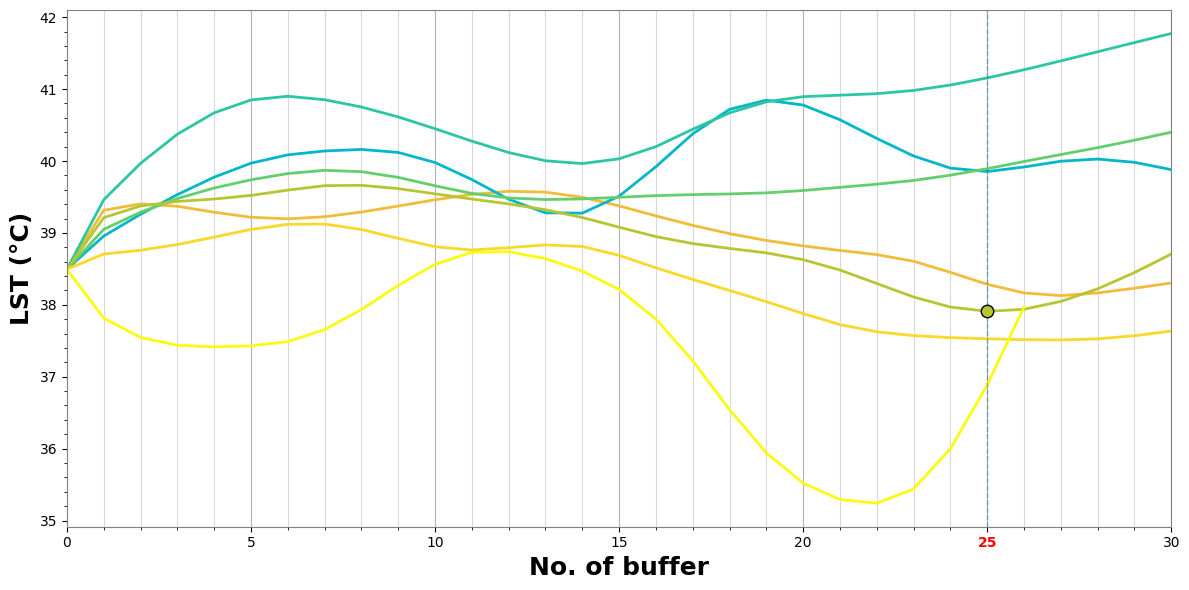

In [148]:
colors = {
    "255": "#03b6ca",
    "285": "#2cc6a4",
    "315": "#63cf6c",
    "345": "#b7c532",
    "15":  "#f1bc3a",
    "45":  "#f8d82b",
    "75":  "#f9fb12"
}

plt.figure(figsize=(12, 6))

# Plot smoothed curves
for direction, group in summer_df_spline.groupby("direction"):
    plt.plot(
        group["distance"],
        group["mean_lst"],
        linewidth=2,
        color=colors.get(direction, "black")
    )

# Plot turning points
for _, row in summer_df_turning.iterrows():
    
    # point
    plt.scatter(
        row["distance"],
        row["lst"],
        s=80,
        color=colors.get(row["direction"], "black"),
        edgecolor="black",
        zorder=5
    )
    
   # Optional: vertical line (very useful visually)
    plt.axvline(
        x=row["distance"],
        linestyle="--",
        linewidth=1,
        alpha=0.5
    )

# Labels
plt.xlabel("No. of buffer", fontsize=18, fontweight="bold")
plt.ylabel("LST (°C)", fontsize=18, fontweight="bold")

# Axis ticks
plt.xticks(np.arange(0, 31, 5))

# Grid styling
plt.grid(which='major', axis='x', color='grey', alpha=0.6)
plt.minorticks_on()
plt.grid(which='minor', axis='x', color='grey', alpha=0.3)

# Clean style
plt.gca().set_facecolor("white")
for spine in plt.gca().spines.values():
    spine.set_edgecolor("grey")

ax = plt.gca()
# base ticks
base_ticks = list(np.arange(0, 31, 5))

# add turning points
turn_ticks = summer_df_turning["distance"].astype(int).tolist()

# merge + remove duplicates + sort
all_ticks = sorted(set(base_ticks + turn_ticks))

ax.set_xticks(all_ticks)
ax.set_xticklabels([str(t) for t in all_ticks])


for label, tick in zip(ax.get_xticklabels(), all_ticks):
    if tick in turn_ticks:
        label.set_fontweight("bold")
        label.set_color("red")   # or use your direction color logic


ax.set_xlim(0, 30)


# Remove legend (as in your original)
plt.legend().remove()

plt.tight_layout()

# Save
# Save
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/summer_turning_points_minimum_LST.png", dpi=300, bbox_inches="tight")

plt.show()


### 2.1.2 Winter

In [100]:
# Load data
winter_df = pd.read_csv("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/data/csv/lst_2022.csv")

# Keep distances < 31
winter_df = winter_df[winter_df["distance"] < 31]

# Ensure correct type
winter_df["direction"] = winter_df["direction"].astype(str)

In [101]:
# 2. Fit GAM curves + compute turning points
winter_df_spline_list = []
winter_turning_points = []

for direction, group in winter_df.groupby("direction"):
    
    group = group.sort_values("distance")
    
    X = group["distance"].values.reshape(-1, 1)
    y = group["mean_lst"].values
    
    # Fit GAM
    gam = GAM(s(0, spline_order=3)).fit(X, y)
    
    # Predict on original distances (for plotting consistency)
    pred = gam.predict(X)
    
    # Force exact value at distance = 0
    idx0 = np.where(group["distance"].values == 0)[0]
    if len(idx0) == 1:
        pred[idx0[0]] = y[idx0[0]]
    
    # Store smoothed curve
    temp = pd.DataFrame({
        "distance": group["distance"].values,
        "mean_lst": pred,
        "direction": direction
    })
    winter_df_spline_list.append(temp)
    
    # --------------------------
    # Turning point calculation
    # --------------------------
    
    # Only compute turning points for selected directions
    if direction in ["315", "345"]:
        
        x_vals = group["distance"].values
        
        # Reference LST at distance = 0
        if len(idx0) == 1:
            y0 = pred[idx0[0]]
        else:
            y0 = pred[0]
        
        # Only consider cooling (below starting LST)
        mask = pred < y0
        
        if np.any(mask):
            idx_min = np.argmin(pred[mask])
            x_valid = x_vals[mask]
            y_valid = pred[mask]
            
            winter_turning_points.append({
                "direction": direction,
                "distance": x_valid[idx_min],
                "lst": y_valid[idx_min]
            })


# Combine curves
winter_df_spline = pd.concat(winter_df_spline_list, ignore_index=True)

# Turning points table
winter_df_turning = pd.DataFrame(winter_turning_points)

print(winter_df_turning)

  direction  distance        lst
0       315        26  14.779259
1       345        27  14.532251


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


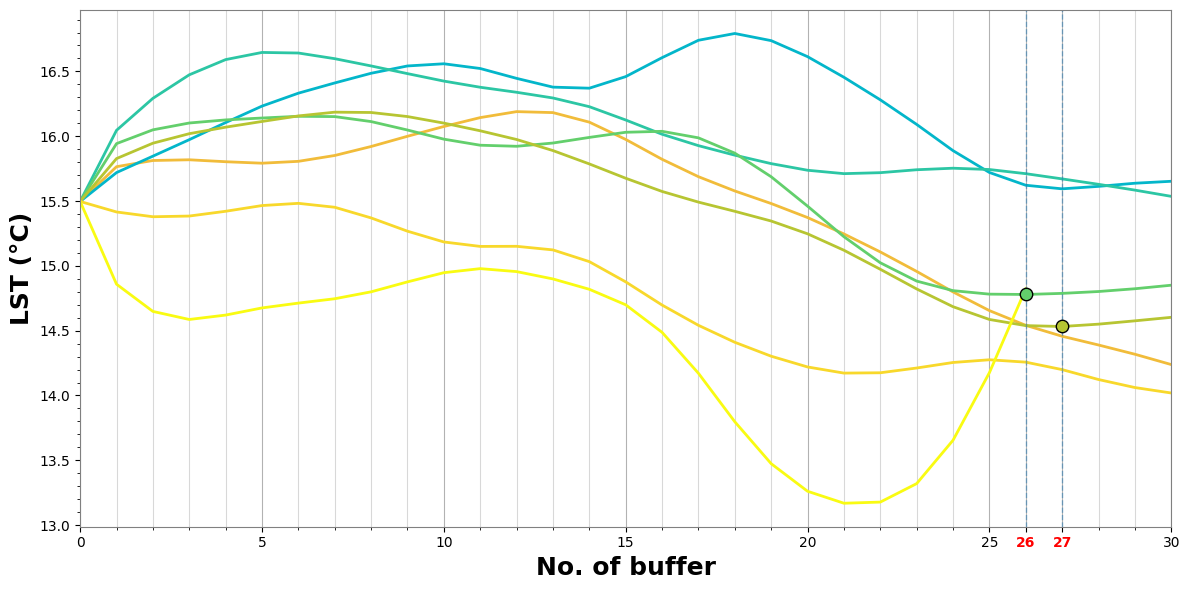

In [149]:
colors = {
    "255": "#03b6ca",
    "285": "#2cc6a4",
    "315": "#63cf6c",
    "345": "#b7c532",
    "15":  "#f1bc3a",
    "45":  "#f8d82b",
    "75":  "#f9fb12"
}

plt.figure(figsize=(12, 6))

# Plot smoothed curves
for direction, group in winter_df_spline.groupby("direction"):
    plt.plot(
        group["distance"],
        group["mean_lst"],
        linewidth=2,
        color=colors.get(direction, "black")
    )

# Plot turning points
for _, row in winter_df_turning.iterrows():
    
    # point
    plt.scatter(
        row["distance"],
        row["lst"],
        s=80,
        color=colors.get(row["direction"], "black"),
        edgecolor="black",
        zorder=5
    )
    
   # Optional: vertical line (very useful visually)
    plt.axvline(
        x=row["distance"],
        linestyle="--",
        linewidth=1,
        alpha=0.5
    )

# Labels
plt.xlabel("No. of buffer", fontsize=18, fontweight="bold")
plt.ylabel("LST (°C)", fontsize=18, fontweight="bold")

# Axis ticks
plt.xticks(np.arange(0, 31, 5))

# Grid styling
plt.grid(which='major', axis='x', color='grey', alpha=0.6)
plt.minorticks_on()
plt.grid(which='minor', axis='x', color='grey', alpha=0.3)

# Clean style
plt.gca().set_facecolor("white")
for spine in plt.gca().spines.values():
    spine.set_edgecolor("grey")

ax = plt.gca()
# base ticks
base_ticks = list(np.arange(0, 31, 5))

# add turning points
turn_ticks = winter_df_turning["distance"].astype(int).tolist()

# merge + remove duplicates + sort
all_ticks = sorted(set(base_ticks + turn_ticks))

ax.set_xticks(all_ticks)
ax.set_xticklabels([str(t) for t in all_ticks])


for label, tick in zip(ax.get_xticklabels(), all_ticks):
    if tick in turn_ticks:
        label.set_fontweight("bold")
        label.set_color("red")   # or use your direction color logic


ax.set_xlim(0, 30)


# Remove legend (as in your original)
plt.legend().remove()

plt.tight_layout()

# Save
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/winter_turning_points_minimum_LST.png", dpi=300, bbox_inches="tight")

plt.show()


## 2.2 Near-zero slope

The near-zero slope turning point represents the buffer distance at which the LST curve becomes nearly flat, meaning that further increases in distance no longer produce meaningful changes in temperature. In other words, it marks the point where the cooling effect of the surrounding landscape stabilizes and reaches a saturation level.

Mathematically, this condition is defined as:

$$
\frac{dT(x)}{dx} \approx 0 \quad \text{for } x = x^*
$$

In discrete form, it is identified as:

$$
x^* = \min \{ x_i \;|\; |\nabla LST(x_i)| < \epsilon \}
$$

Where:
* **$\text{LST}(x_i)$** is the LST at distance $x_i$.
* **$\nabla LST(x_i)$** is the numerical slope.
* **$\epsilon$** is a small threshold defining “near-zero” change.



### 2.2.1 Summer

In [150]:
summer_turning_points_near_zero = []

for direction, group in summer_df_spline.groupby("direction"):

    group = group.sort_values("distance")

    x_vals = group["distance"].values
    y_vals = group["mean_lst"].values

    dydx = np.gradient(y_vals, x_vals)

    idx0 = np.where(x_vals == 0)[0]
    y0 = y_vals[idx0[0]] if len(idx0) > 0 else y_vals[0]

    mask = y_vals < y0

    x_masked = x_vals[mask]
    y_masked = y_vals[mask]
    slope_masked = dydx[mask]

    threshold = 0.01

    near_zero_idx = np.where(np.abs(slope_masked) < threshold)[0]

    if len(near_zero_idx) > 0:

        idx = near_zero_idx[0]

        summer_turning_points_near_zero.append({
            "direction": direction,
            "distance": x_masked[idx],
            "lst": y_masked[idx],
            "method": "near_zero_slope"
        })


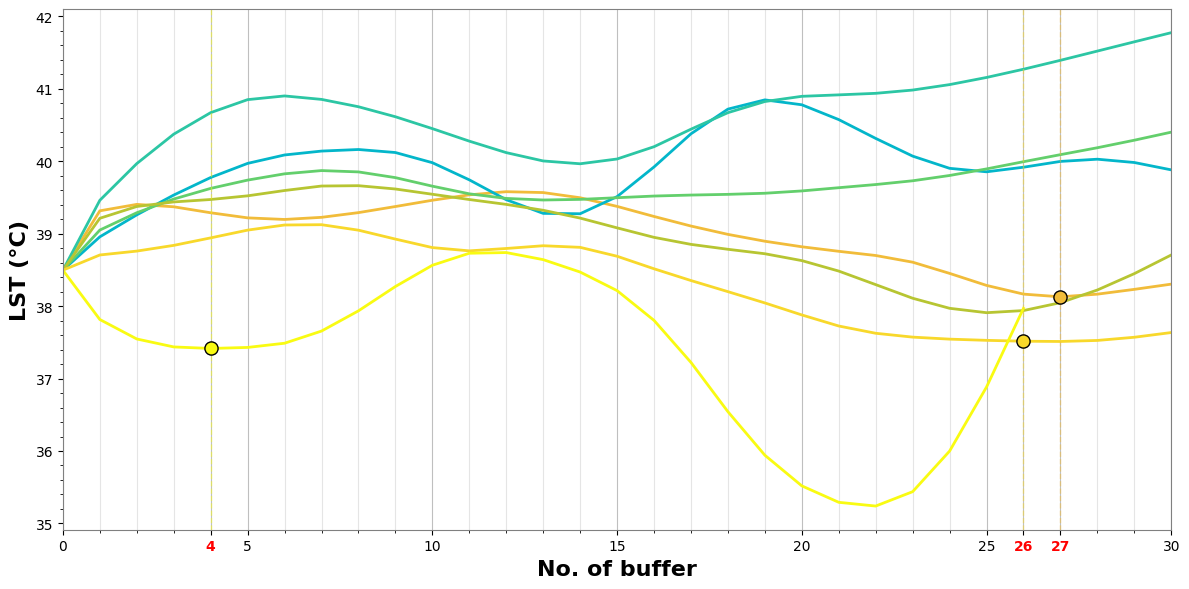

In [151]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_tp = pd.DataFrame(summer_turning_points_near_zero)

# --------------------------
# 0. Create figure FIRST
# --------------------------
plt.figure(figsize=(12, 6))
ax = plt.gca()

# --------------------------
# 1. Plot curves
# --------------------------
for direction, group in summer_df_spline.groupby("direction"):

    group = group.sort_values("distance")

    plt.plot(
        group["distance"],
        group["mean_lst"],
        linewidth=2,
        color=colors.get(direction, "black"),
        label=f"Direction {direction}"
    )

# --------------------------
# 2. Plot near-zero slope points
# --------------------------
for _, row in df_tp.iterrows():

    plt.scatter(
        row["distance"],
        row["lst"],
        s=90,
        color=colors.get(row["direction"], "black"),
        edgecolor="black",
        zorder=5
    )

    # vertical line (optional but useful)
    plt.axvline(
        x=row["distance"],
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        color=colors.get(row["direction"], "black")
    )

# --------------------------
# 3. Labels
# --------------------------
plt.xlabel("No. of buffer", fontsize=16, fontweight="bold")
plt.ylabel("LST (°C)", fontsize=16, fontweight="bold")


# --------------------------
# 4. X-axis ticks
# --------------------------
plt.xticks(np.arange(0, 31, 5))

ax = plt.gca()

# --------------------------
# Base ticks
# --------------------------
base_ticks = list(np.arange(0, 31, 5))

# --------------------------
# Turning points (near-zero slope)
# --------------------------
turn_ticks = df_tp["distance"].astype(int).tolist()

# --------------------------
# Merge + clean
# --------------------------
all_ticks = sorted(set(base_ticks + turn_ticks))

ax.set_xticks(all_ticks)
ax.set_xticklabels([str(t) for t in all_ticks])

# --------------------------
# Highlight turning points
# --------------------------
for label, tick in zip(ax.get_xticklabels(), all_ticks):
    if tick in turn_ticks:
        label.set_fontweight("bold")
        label.set_color("red")   # you can replace with colors dict later


# --------------------------
# 5. Grid styling
# --------------------------
plt.grid(axis="x", which="major", color="grey", alpha=0.5)
plt.minorticks_on()
plt.grid(axis="x", which="minor", color="grey", alpha=0.2)

ax.set_xlim(0, 30)

# --------------------------
# 6. Clean spines
# --------------------------
for spine in ax.spines.values():
    spine.set_edgecolor("grey")

ax.set_facecolor("white")

# --------------------------
# 7. Legend (bottom)
# --------------------------
#plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4)

plt.tight_layout()

# Save
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/summer_turning_points_near_zero_slope.png", dpi=300, bbox_inches="tight")

plt.show()


### 2.2.2 Winter

In [131]:
winter_turning_points_near_zero = []

for direction, group in winter_df_spline.groupby("direction"):

    group = group.sort_values("distance")

    x_vals = group["distance"].values
    y_vals = group["mean_lst"].values

    dydx = np.gradient(y_vals, x_vals)

    idx0 = np.where(x_vals == 0)[0]
    y0 = y_vals[idx0[0]] if len(idx0) > 0 else y_vals[0]

    mask = y_vals < y0

    x_masked = x_vals[mask]
    y_masked = y_vals[mask]
    slope_masked = dydx[mask]

    threshold = 0.01

    near_zero_idx = np.where(np.abs(slope_masked) < threshold)[0]

    if len(near_zero_idx) > 0:

        idx = near_zero_idx[0]

        winter_turning_points_near_zero.append({
            "direction": direction,
            "distance": x_masked[idx],
            "lst": y_masked[idx],
            "method": "near_zero_slope"
        })



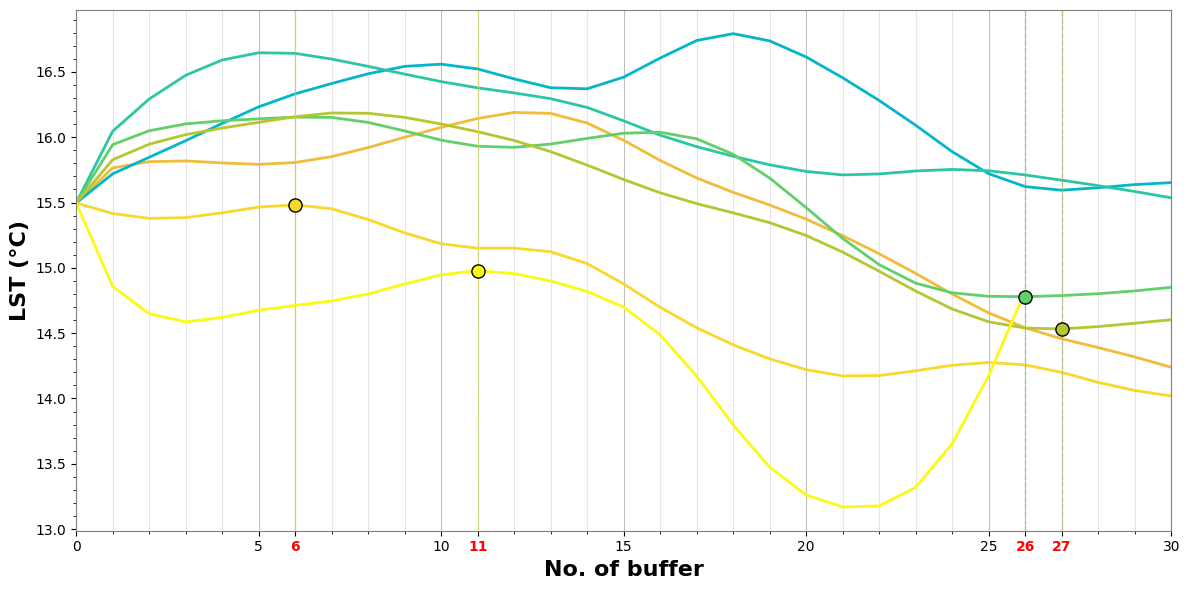

In [145]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_tp = pd.DataFrame(winter_turning_points_near_zero)


# --------------------------
# 0. Create figure FIRST
# --------------------------
plt.figure(figsize=(12, 6))
ax = plt.gca()

# --------------------------
# 1. Plot curves
# --------------------------
for direction, group in winter_df_spline.groupby("direction"):

    group = group.sort_values("distance")

    plt.plot(
        group["distance"],
        group["mean_lst"],
        linewidth=2,
        color=colors.get(direction, "black"),
        label=f"Direction {direction}"
    )

# --------------------------
# 2. Plot near-zero slope points
# --------------------------
for _, row in df_tp.iterrows():

    plt.scatter(
        row["distance"],
        row["lst"],
        s=90,
        color=colors.get(row["direction"], "black"),
        edgecolor="black",
        zorder=5
    )

    # vertical line (optional but useful)
    plt.axvline(
        x=row["distance"],
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        color=colors.get(row["direction"], "black")
    )

# --------------------------
# 3. Labels
# --------------------------
plt.xlabel("No. of buffer", fontsize=16, fontweight="bold")
plt.ylabel("LST (°C)", fontsize=16, fontweight="bold")


# --------------------------
# 4. X-axis ticks
# --------------------------
plt.xticks(np.arange(0, 31, 5))

ax = plt.gca()

# --------------------------
# Base ticks
# --------------------------
base_ticks = list(np.arange(0, 31, 5))

# --------------------------
# Turning points (near-zero slope)
# --------------------------
turn_ticks = df_tp["distance"].astype(int).tolist()

# --------------------------
# Merge + clean
# --------------------------
all_ticks = sorted(set(base_ticks + turn_ticks))

ax.set_xticks(all_ticks)
ax.set_xticklabels([str(t) for t in all_ticks])

# --------------------------
# Highlight turning points
# --------------------------
for label, tick in zip(ax.get_xticklabels(), all_ticks):
    if tick in turn_ticks:
        label.set_fontweight("bold")
        label.set_color("red")   # you can replace with colors dict later


# --------------------------
# 5. Grid styling
# --------------------------
plt.grid(axis="x", which="major", color="grey", alpha=0.5)
plt.minorticks_on()
plt.grid(axis="x", which="minor", color="grey", alpha=0.2)

ax.set_xlim(0, 30)

# --------------------------
# 6. Clean spines
# --------------------------
for spine in ax.spines.values():
    spine.set_edgecolor("grey")

ax.set_facecolor("white")

# --------------------------
# 7. Legend (bottom)
# --------------------------
#plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4)

plt.tight_layout()

# Save
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/winter_turning_points_near_zero_slope.png", dpi=300, bbox_inches="tight")

plt.show()
